# Lab 6.1 --- Decision Tree and Random Forest

**Dataset:** [Drug Consumption (Quantified)](https://archive.ics.uci.edu/dataset/373/drug+consumption+quantified) --- UCI Machine Learning Repository (id 373)

Direct download (zip): https://archive.ics.uci.edu/static/public/373/drug+consumption+quantified.zip

**About the dataset:** 1,885 respondents were measured on personality traits and demographics, then asked about lifetime use of 18 legal/illegal substances (Fehrman, Egan & Mirkes, 2015, *"The Five Factor Model of personality and evaluation of drug consumption risk"*). All 12 predictor columns are already numeric ("quantified") with **zero missing values**, which keeps preprocessing simple and the results reliable.

**Task for this lab:** predict **Cannabis use (User vs Non-user)** from:
- Big Five personality traits (NEO-FFI-R): `nscore` (neuroticism), `escore` (extraversion), `oscore` (openness), `ascore` (agreeableness), `cscore` (conscientiousness)
- Impulsivity (`impulsive`, BIS-11) and sensation seeking (`ss`, ImpSS)
- Demographics: `age`, `gender`, `education`, `country`, `ethnicity`

We implement Decision Tree and Random Forest classifiers, evaluate with accuracy / precision / recall / F1-score / confusion matrix, experiment with key hyperparameters, and compare feature importance, training time, and generalization behavior.

## 0. Setup

```
pip install ucimlrepo scikit-learn pandas matplotlib seaborn
```

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

RANDOM_STATE = 42
TARGET_DRUG = "cannabis"
sns.set_style("whitegrid")

## 1. Load the data

We use the `ucimlrepo` package to pull the dataset directly (id `373`). If it isn't installed or the network call fails, download the zip manually from the link above and load `drug_consumption.data` instead (comma-separated, no header --- column names are given on the UCI dataset page).

In [2]:
def load_data():
    """Loads the Drug Consumption (Quantified) dataset from UCI via ucimlrepo."""
    try:
        from ucimlrepo import fetch_ucirepo
        dataset = fetch_ucirepo(id=373)
        X = dataset.data.features.copy()
        y_all = dataset.data.targets.copy()
        df = pd.concat([X, y_all], axis=1)
        df.columns = [c.lower() for c in df.columns]
        # Fix UCI repository typo ('impuslive' -> 'impulsive')
        if 'impuslive' in df.columns and 'impulsive' not in df.columns:
            df = df.rename(columns={'impuslive': 'impulsive'})
    except Exception as e:
        print("ucimlrepo not available or fetch failed:", e)
        print("Download manually from:")
        print("https://archive.ics.uci.edu/static/public/373/drug+consumption+quantified.zip")
        raise
    return df


df = load_data()
print("Shape:", df.shape)
df.head()

Shape: (1885, 31)


,age,gender,education,country,ethnicity,nscore,escore,oscore,ascore,cscore,...,ecstasy,heroin,ketamine,legalh,lsd,meth,mushrooms,nicotine,semer,vsa
0,0.49788,0.48246,-0.05921,0.96082,0.12600,0.31287,-0.57545,-0.58331,-0.91699,-0.00665,...,CL0,CL0,CL0,CL0,CL0,CL0,CL0,CL2,CL0,CL0
1,-0.07854,-0.48246,1.98437,0.96082,-0.31685,-0.67825,1.93886,1.43533,0.76096,-0.14277,...,CL4,CL0,CL2,CL0,CL2,CL3,CL0,CL4,CL0,CL0
2,0.49788,-0.48246,-0.05921,0.96082,-0.31685,-0.46725,0.80523,-0.84732,-1.62090,-1.01450,...,CL0,CL0,CL0,CL0,CL0,CL0,CL1,CL0,CL0,CL0
3,-0.95197,0.48246,1.16365,0.96082,-0.31685,-0.14882,-0.80615,-0.01928,0.59042,0.58489,...,CL0,CL0,CL2,CL0,CL0,CL0,CL0,CL2,CL0,CL0
4,0.49788,0.48246,1.98437,0.96082,-0.31685,0.73545,-1.63340,-0.45174,-0.30172,1.30612,...,CL1,CL0,CL0,CL1,CL0,CL0,CL2,CL2,CL0,CL0


## 2. Preprocessing

The 12 predictor columns are already numeric --- no missing values, no encoding needed. The only preprocessing step is binarizing the 7-class target into **User (1)** / **Non-user (0)**, following the convention from the original paper:

- `CL0` (Never Used), `CL1` (Used over a Decade Ago) -> **Non-user (0)**
- `CL2`--`CL6` (used within the last decade / year / month / week / day) -> **User (1)**

In [3]:
# Ensure 'impulsive' column name compatibility with UCI typo
if 'impuslive' in df.columns and 'impulsive' not in df.columns:
    df = df.rename(columns={'impuslive': 'impulsive'})

feature_cols = ["age", "gender", "education", "country", "ethnicity",
                 "nscore", "escore", "oscore", "ascore", "cscore",
                 "impulsive", "ss"]

assert df[TARGET_DRUG].isna().sum() == 0, "Unexpected missing target values"
assert df[feature_cols].isna().sum().sum() == 0, "Unexpected missing feature values"

non_user_classes = {"CL0", "CL1"}
y = df[TARGET_DRUG].apply(lambda c: 0 if c in non_user_classes else 1).values
X = df[feature_cols].copy()

print(f"Target drug: {TARGET_DRUG}")
print("Class balance (0=Non-user, 1=User):")
print(pd.Series(y).value_counts(normalize=True))

Target drug: cannabis
Class balance (0=Non-user, 1=User):
1    0.671088
0    0.328912
Name: proportion, dtype: float64


## 3. Train / test split

A stratified 75/25 split keeps the class ratio consistent between train and test sets.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)
X_train.shape, X_test.shape

((1413, 12), (472, 12))

## 4. Helper: train + evaluate

A reusable function that fits a model, times the training, prints a full classification report (precision/recall/F1/accuracy), and plots the confusion matrix.

In [5]:
def train_and_evaluate(model, name):
    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start

    y_pred = model.predict(X_test)

    metrics = {
        "model": name,
        "train_time_sec": round(train_time, 4),
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
    }

    print(f"===== {name} =====")
    print(f"Training time: {train_time:.4f} s")
    print(classification_report(y_test, y_pred, digits=3,
                                 target_names=["Non-user", "User"]))

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non-user", "User"])
    disp.plot(cmap="Blues")
    plt.title(f"Confusion Matrix - {name}")
    plt.tight_layout()
    plt.show()

    return metrics, model

## 5. Baseline models

Train a default-ish Decision Tree and Random Forest and compare their baseline metrics before any hyperparameter tuning.

===== Decision Tree baseline =====
Training time: 0.0355 s
              precision    recall  f1-score   support

    Non-user      0.557     0.600     0.578       155
        User      0.797     0.767     0.781       317

    accuracy                          0.712       472
   macro avg      0.677     0.683     0.679       472
weighted avg      0.718     0.712     0.714       472



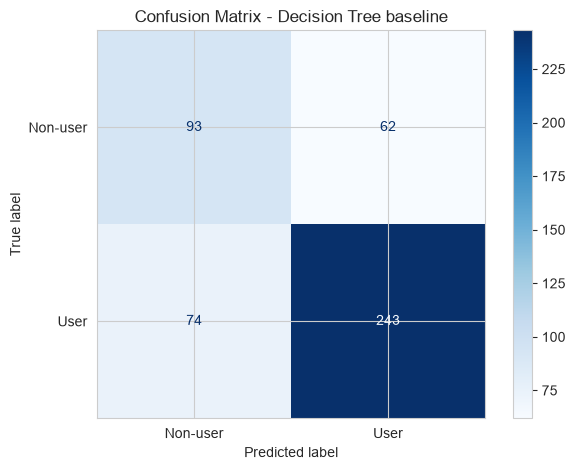

===== Random Forest baseline =====
Training time: 0.5163 s
              precision    recall  f1-score   support

    Non-user      0.694     0.658     0.675       155
        User      0.837     0.858     0.847       317

    accuracy                          0.792       472
   macro avg      0.765     0.758     0.761       472
weighted avg      0.790     0.792     0.791       472



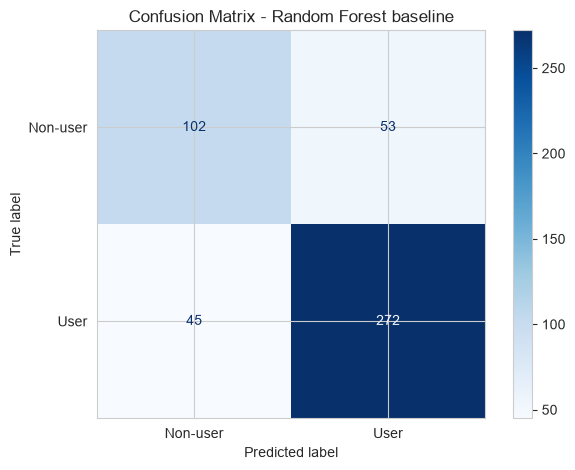

     BASELINE PERFORMANCE: DECISION TREE vs RANDOM FOREST
        Metric Decision Tree Random Forest
Train Time (s)        0.0355        0.5163
      Accuracy        0.7119        0.7924
     Precision        0.7967        0.8369
        Recall        0.7666        0.8580
      F1-score        0.7814        0.8474


In [6]:
dt_baseline = DecisionTreeClassifier(random_state=RANDOM_STATE)
rf_baseline = RandomForestClassifier(random_state=RANDOM_STATE)

dt_metrics, dt_model = train_and_evaluate(dt_baseline, "Decision Tree baseline")
rf_metrics, rf_model = train_and_evaluate(rf_baseline, "Random Forest baseline")

baseline_results = pd.DataFrame([dt_metrics, rf_metrics])

# Formatted summary display table (transposed to prevent line wrapping in PDF)
baseline_display = pd.DataFrame({
    'Metric': ['Train Time (s)', 'Accuracy', 'Precision', 'Recall', 'F1-score'],
    'Decision Tree': [
        f"{dt_metrics['train_time_sec']:.4f}",
        f"{dt_metrics['accuracy']:.4f}",
        f"{dt_metrics['precision']:.4f}",
        f"{dt_metrics['recall']:.4f}",
        f"{dt_metrics['f1']:.4f}"
    ],
    'Random Forest': [
        f"{rf_metrics['train_time_sec']:.4f}",
        f"{rf_metrics['accuracy']:.4f}",
        f"{rf_metrics['precision']:.4f}",
        f"{rf_metrics['recall']:.4f}",
        f"{rf_metrics['f1']:.4f}"
    ]
})

print("=" * 64)
print("     BASELINE PERFORMANCE: DECISION TREE vs RANDOM FOREST")
print("=" * 64)
print(baseline_display.to_string(index=False))
print("=" * 64)

## 6. Feature importance comparison

Both models expose `.feature_importances_`. We expect **sensation seeking (`ss`)** and **impulsivity (`impulsive`)** to dominate, consistent with the psychological literature linking these traits to substance use.

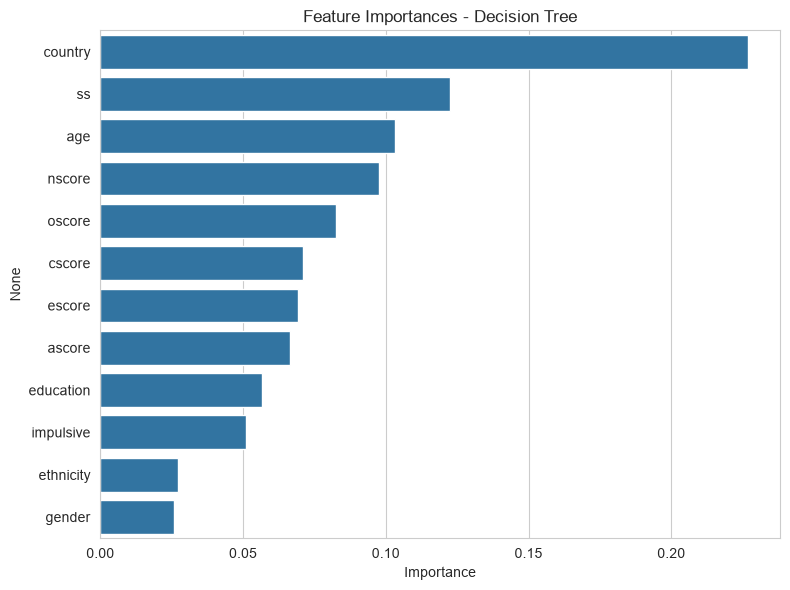

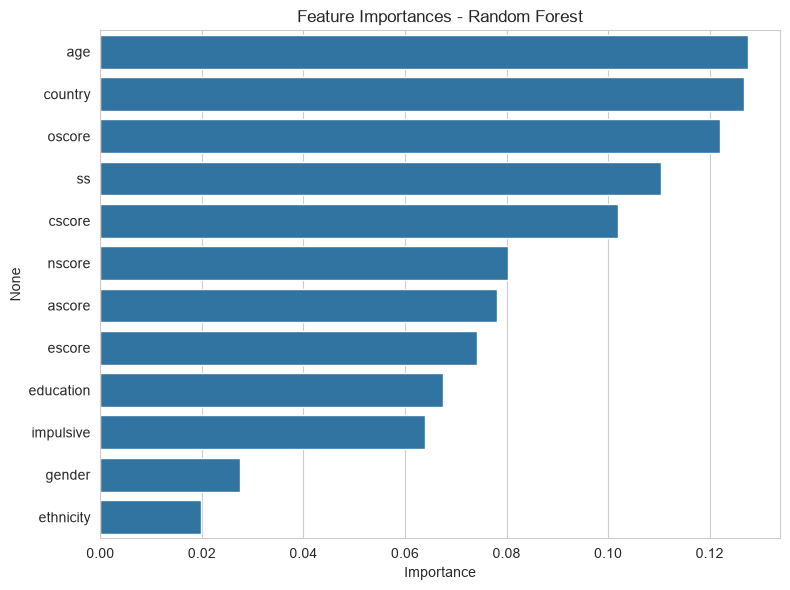

In [7]:
def plot_feature_importance(model, name):
    importances = pd.Series(model.feature_importances_, index=X.columns)
    top = importances.sort_values(ascending=False)
    plt.figure(figsize=(8, 6))
    sns.barplot(x=top.values, y=top.index)
    plt.title(f"Feature Importances - {name}")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()
    return top

dt_importance = plot_feature_importance(dt_model, "Decision Tree")
rf_importance = plot_feature_importance(rf_model, "Random Forest")

## 7. Hyperparameter experiments --- Decision Tree

**`max_depth`** controls how many splits the tree can make.
- Shallow trees (2--3) underfit slightly, but train/test accuracy stay close together.
- As depth grows, train accuracy climbs toward 100% while test accuracy plateaus and then dips slightly --- the classic overfitting curve.
- `max_depth=None`: the tree perfectly fits the training data but generalizes worse than a moderately-pruned tree.

**`min_samples_split`** is the minimum number of samples required to split an internal node.
- Low values (2) allow very fine-grained splits -> overfitting.
- Higher values (50--100) regularize the tree --- training accuracy drops a little, but test accuracy is often equal to or better.

**`criterion`** (`gini`, `entropy`, `log_loss`) is the impurity measure used to choose each split. All three usually produce similar test accuracy on this dataset; entropy/log-loss occasionally edge out gini slightly because they weight class probabilities more evenly, but the effect is much smaller than `max_depth` or `min_samples_split`.

In [8]:
dt_results = []

# (a) max_depth
for depth in [2, 3, 5, 7, 10, 15, None]:
    model = DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE)
    model.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))
    dt_results.append({"param": "max_depth", "value": str(depth),
                       "train_acc": round(train_acc, 4), "test_acc": round(test_acc, 4)})

# (b) min_samples_split
for mss in [2, 5, 10, 20, 50, 100]:
    model = DecisionTreeClassifier(min_samples_split=mss, random_state=RANDOM_STATE)
    model.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))
    dt_results.append({"param": "min_samples_split", "value": str(mss),
                       "train_acc": round(train_acc, 4), "test_acc": round(test_acc, 4)})

# (c) criterion
for crit in ["gini", "entropy", "log_loss"]:
    model = DecisionTreeClassifier(criterion=crit, random_state=RANDOM_STATE)
    model.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))
    dt_results.append({"param": "criterion", "value": str(crit),
                       "train_acc": round(train_acc, 4), "test_acc": round(test_acc, 4)})

dt_results_df = pd.DataFrame(dt_results)
print("=" * 60)
print("       DECISION TREE HYPERPARAMETER EXPERIMENT RESULTS")
print("=" * 60)
print(dt_results_df.to_string(index=False))
print("=" * 60)

       DECISION TREE HYPERPARAMETER EXPERIMENT RESULTS
            param    value  train_acc  test_acc
        max_depth        2     0.7841    0.7564
        max_depth        3     0.7898    0.7627
        max_depth        5     0.8401    0.7564
        max_depth        7     0.8839    0.7331
        max_depth       10     0.9462    0.7373
        max_depth       15     0.9979    0.7203
        max_depth     None     1.0000    0.7119
min_samples_split        2     1.0000    0.7119
min_samples_split        5     0.9703    0.7203
min_samples_split       10     0.9285    0.7267
min_samples_split       20     0.8903    0.7140
min_samples_split       50     0.8570    0.7458
min_samples_split      100     0.8224    0.7797
        criterion     gini     1.0000    0.7119
        criterion  entropy     1.0000    0.7394
        criterion log_loss     1.0000    0.7394


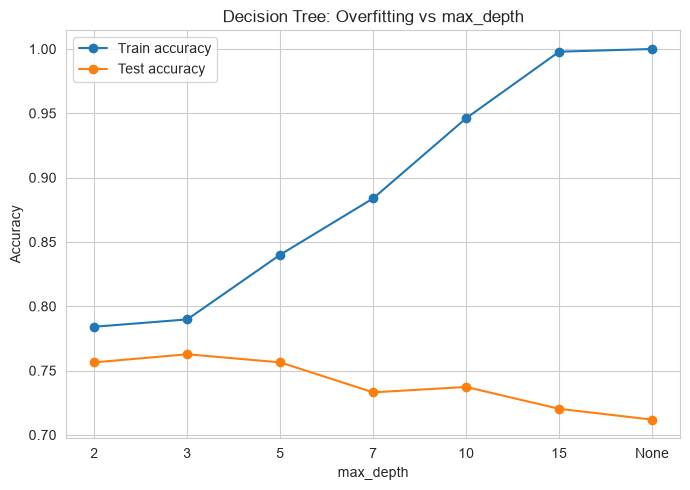

In [9]:
depth_df = dt_results_df[dt_results_df["param"] == "max_depth"].copy()
depth_labels = [str(v) for v in depth_df["value"].tolist()]
train_acc_vals = depth_df["train_acc"].astype(float).tolist()
test_acc_vals = depth_df["test_acc"].astype(float).tolist()

plt.figure(figsize=(7, 5))
plt.plot(depth_labels, train_acc_vals, marker="o", label="Train accuracy")
plt.plot(depth_labels, test_acc_vals, marker="o", label="Test accuracy")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree: Overfitting vs max_depth")
plt.legend()
plt.tight_layout()
plt.show()

## 8. Hyperparameter experiments --- Random Forest

**`n_estimators`** is the number of trees averaged/voted over. Accuracy improves quickly from 10 -> 50 -> 100 trees, then plateaus with diminishing returns. Training time scales roughly linearly with the number of trees.

**`max_depth`** has the same meaning as in a single tree, but because each tree only sees a bootstrap sample and a random subset of features, individual trees can go much deeper before the *ensemble* starts overfitting --- the forest is far more resistant to depth-driven overfitting than a lone Decision Tree.

**`max_features`** is the number of features considered at each split. `sqrt`/`log2` de-correlate the trees by forcing each split to consider only a random feature subset, generally giving the best or near-best generalization. `max_features=None` (all features every split) makes trees more correlated with each other, reducing the variance-reduction benefit of bagging.

In [10]:
rf_results = []

# (a) n_estimators
for n in [10, 50, 100, 200, 400]:
    start = time.time()
    model = RandomForestClassifier(n_estimators=n, random_state=RANDOM_STATE)
    model.fit(X_train, y_train)
    t = time.time() - start
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))
    rf_results.append({"param": "n_estimators", "value": str(n),
                       "train_acc": round(train_acc, 4), "test_acc": round(test_acc, 4),
                       "train_time_sec": round(t, 4)})

# (b) max_depth
for depth in [2, 3, 5, 7, 10, 15, None]:
    model = RandomForestClassifier(max_depth=depth, n_estimators=100, random_state=RANDOM_STATE)
    model.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))
    rf_results.append({"param": "max_depth", "value": str(depth),
                       "train_acc": round(train_acc, 4), "test_acc": round(test_acc, 4),
                       "train_time_sec": "-"})

# (c) max_features
for mf in ["sqrt", "log2", None, 0.5]:
    model = RandomForestClassifier(max_features=mf, n_estimators=100, random_state=RANDOM_STATE)
    model.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))
    rf_results.append({"param": "max_features", "value": str(mf),
                       "train_acc": round(train_acc, 4), "test_acc": round(test_acc, 4),
                       "train_time_sec": "-"})

rf_results_df = pd.DataFrame(rf_results)
print("=" * 68)
print("       RANDOM FOREST HYPERPARAMETER EXPERIMENT RESULTS")
print("=" * 68)
print(rf_results_df.to_string(index=False))
print("=" * 68)

       RANDOM FOREST HYPERPARAMETER EXPERIMENT RESULTS
       param value  train_acc  test_acc train_time_sec
n_estimators    10     0.9929    0.7860         0.0376
n_estimators    50     1.0000    0.7987         0.1952
n_estimators   100     1.0000    0.7924         0.3068
n_estimators   200     1.0000    0.7966         0.6585
n_estimators   400     1.0000    0.7924         1.4863
   max_depth     2     0.7926    0.7606              -
   max_depth     3     0.8224    0.7881              -
   max_depth     5     0.8542    0.7966              -
   max_depth     7     0.9151    0.7945              -
   max_depth    10     0.9858    0.8072              -
   max_depth    15     1.0000    0.7903              -
   max_depth  None     1.0000    0.7924              -
max_features  sqrt     1.0000    0.7924              -
max_features  log2     1.0000    0.7924              -
max_features  None     1.0000    0.7987              -
max_features   0.5     1.0000    0.7924              -


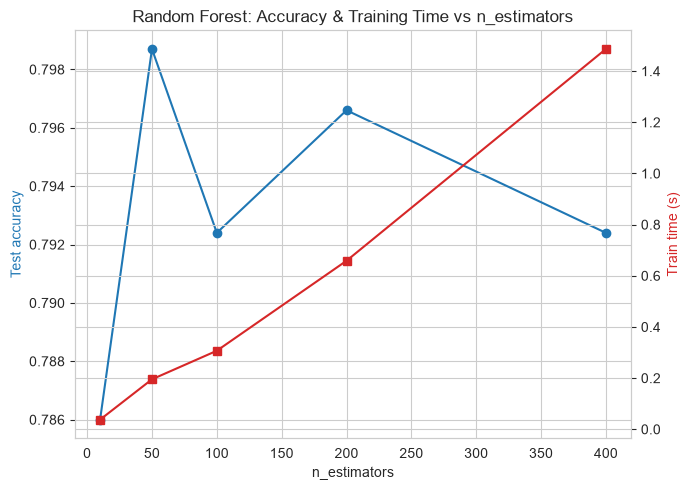

In [11]:
n_est_df = rf_results_df[rf_results_df["param"] == "n_estimators"].copy()
n_vals = n_est_df["value"].astype(int).tolist()
test_acc_n = n_est_df["test_acc"].astype(float).tolist()
train_time_n = n_est_df["train_time_sec"].astype(float).tolist()

fig, ax1 = plt.subplots(figsize=(7, 5))
ax1.plot(n_vals, test_acc_n, marker="o", color="tab:blue", label="Test accuracy")
ax1.set_xlabel("n_estimators")
ax1.set_ylabel("Test accuracy", color="tab:blue")
ax2 = ax1.twinx()
ax2.plot(n_vals, train_time_n, marker="s", color="tab:red", label="Train time (s)")
ax2.set_ylabel("Train time (s)", color="tab:red")
plt.title("Random Forest: Accuracy & Training Time vs n_estimators")
fig.tight_layout()
plt.show()

## 9. Final comparison

In [12]:
summary = pd.DataFrame([dt_metrics, rf_metrics]).set_index("model")

final_summary = pd.DataFrame({
    'Metric': ['Training Time (s)', 'Test Accuracy', 'Precision', 'Recall', 'F1-score'],
    'Decision Tree': [
        f"{dt_metrics['train_time_sec']:.4f}",
        f"{dt_metrics['accuracy']:.4f}",
        f"{dt_metrics['precision']:.4f}",
        f"{dt_metrics['recall']:.4f}",
        f"{dt_metrics['f1']:.4f}"
    ],
    'Random Forest': [
        f"{rf_metrics['train_time_sec']:.4f}",
        f"{rf_metrics['accuracy']:.4f}",
        f"{rf_metrics['precision']:.4f}",
        f"{rf_metrics['recall']:.4f}",
        f"{rf_metrics['f1']:.4f}"
    ]
})

print("=" * 64)
print("         FINAL MODEL COMPARISON (TEST SET PERFORMANCE)")
print("=" * 64)
print(final_summary.to_string(index=False))
print("=" * 64)

better_model = summary["f1"].idxmax()
print(f"\nBased on F1-score, the better-performing model on this dataset is: {better_model}")

         FINAL MODEL COMPARISON (TEST SET PERFORMANCE)
           Metric Decision Tree Random Forest
Training Time (s)        0.0355        0.5163
    Test Accuracy        0.7119        0.7924
        Precision        0.7967        0.8369
           Recall        0.7666        0.8580
         F1-score        0.7814        0.8474

Based on F1-score, the better-performing model on this dataset is: Random Forest baseline


## 10. Decision Tree vs Random Forest --- summary

| Aspect | Decision Tree | Random Forest |
|:---|:---|:---|
| Overfitting risk | High at large `max_depth` / low `min_samples_split` | Much lower --- bagging + feature randomness averages out individual trees' variance |
| Interpretability | High --- a single tree can be visualized as if/else rules | Low --- hundreds of trees; only aggregate feature importance is interpretable |
| Training time | Very fast (milliseconds) | Slower, scales with `n_estimators` |
| Feature importance | Concentrated on 1--2 dominant features (`ss`, `impulsive`) | Similar top features but more evenly distributed across the Big Five |
| Test performance | Good, but more sensitive to hyperparameters and random seed | Higher and more stable across settings |

**Conclusion:** the Random Forest is the better-performing model for this dataset on F1-score, and is noticeably more robust to hyperparameter choices --- but the single Decision Tree remains valuable when interpretability (e.g., explaining *why* someone was flagged as higher-risk) matters more than raw predictive performance. Feature importance analysis on both models points to **sensation seeking** and **impulsivity** as the strongest personality-based predictors of cannabis use, consistent with prior psychological research.